# Importação dos Dados

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Análise Descritiva

In [12]:
df = pd.read_csv(
    r'C:\Users\negri\OneDrive\Documentos\GitHub\Hashtag_AnaliseDados\Python\Cursos\PUC Ciência de Dados\Projetos\Modelos de Regressão\Aulas\04.5_Atividade\SUV_Network_Ads.csv',
    sep=',',
    encoding='latin-1'
)

df.head(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


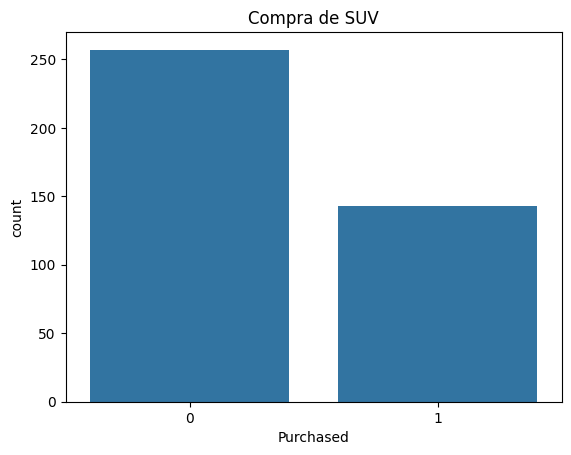

In [13]:
sns.countplot(x='Purchased', data=df)
plt.title("Compra de SUV")
plt.show()

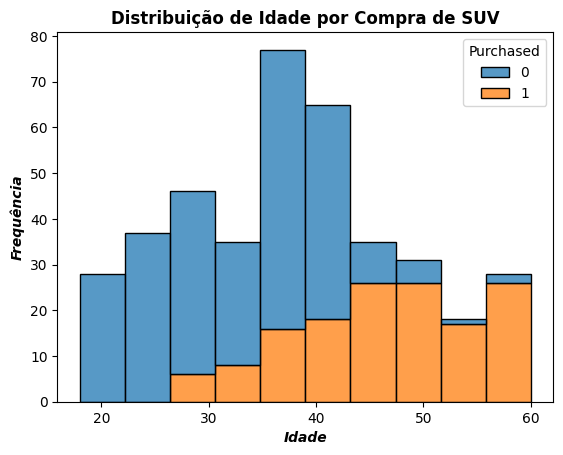

In [55]:
sns.histplot(data=df, x='Age', hue='Purchased', multiple='stack', bins=10)
plt.title("Distribuição de Idade por Compra de SUV", fontweight='bold')
plt.xlabel("Idade", fontstyle='italic', fontweight='bold')
plt.ylabel("Frequência", fontstyle='italic', fontweight='bold')
plt.show()

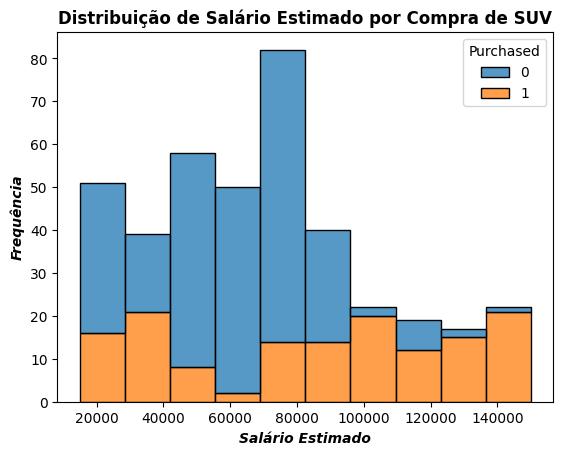

In [56]:
sns.histplot(data=df, x='EstimatedSalary', hue='Purchased', multiple='stack', bins=10)
plt.title("Distribuição de Salário Estimado por Compra de SUV", fontweight='bold')
plt.xlabel("Salário Estimado", fontstyle='italic', fontweight='bold')
plt.ylabel("Frequência", fontstyle='italic', fontweight='bold')
plt.show()

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [17]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [18]:
df = df.fillna(0) # Preenche valores ausentes com 0 (Caso tenha algum)

In [ ]:
df['Gender'] = (
    df['Gender'].str.strip().str.title().map({'Male': 1,'Female': 0})
)

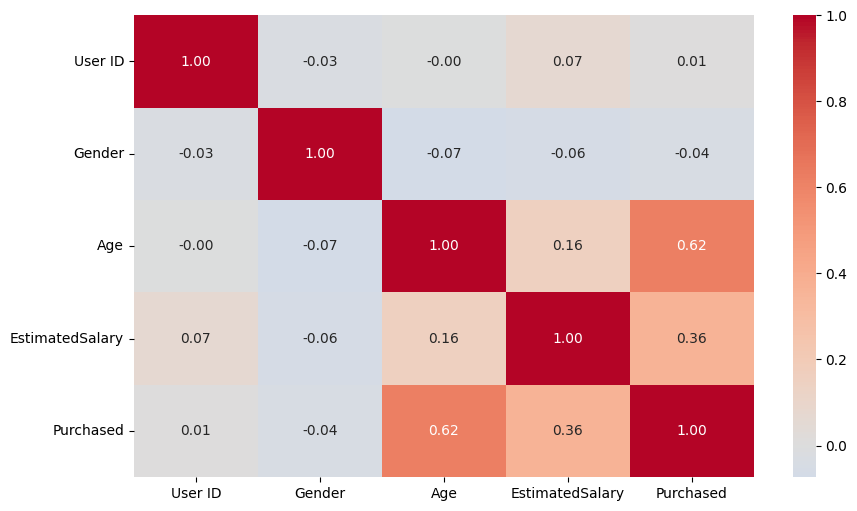

In [20]:
plt.figure(figsize=(10,6))
#sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f', center=0)
sns.heatmap(df.corr(),annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.show()

# Modelo de Regressão

In [21]:
# Criando Modelo de Regressão usando todas as variáveis
Y = df['Purchased'] # Variavel Dependente target
X = df[['Age', 'EstimatedSalary']] # Variáveis Independentes 

X = pd.get_dummies(X, dtype=int)
X = sm.add_constant(X) # Adiciona uma constante 

In [22]:
modelo = sm.Logit(Y, X)
resultado = modelo.fit()

print(resultado.summary())

Optimization terminated successfully.
         Current function value: 0.346314
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:              Purchased   No. Observations:                  400
Model:                          Logit   Df Residuals:                      397
Method:                           MLE   Df Model:                            2
Date:                Mon, 29 Jun 2026   Pseudo R-squ.:                  0.4688
Time:                        19:14:30   Log-Likelihood:                -138.53
converged:                       True   LL-Null:                       -260.79
Covariance Type:            nonrobust   LLR p-value:                 7.995e-54
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -12.4340      1.300     -9.566      0.000     -14.982      -9.886
Age           

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor 
vif = pd.DataFrame()
vif["Variável"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif

,Variável,VIF
0,Age,4.575819
1,EstimatedSalary,4.575819


In [35]:
X = df[['Age','EstimatedSalary']]
y = df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [36]:
modelo = LogisticRegression()

modelo.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [37]:
pred = modelo.predict(X_test)

In [39]:
accuracy_score(y_test,pred)

0.8875

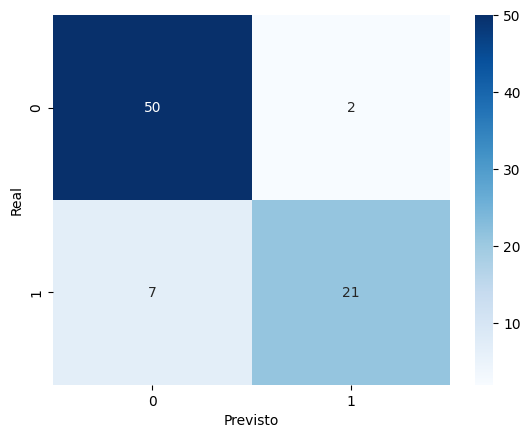

In [42]:
cm = confusion_matrix(y_test,pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

In [44]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92        52
           1       0.91      0.75      0.82        28

    accuracy                           0.89        80
   macro avg       0.90      0.86      0.87        80
weighted avg       0.89      0.89      0.88        80



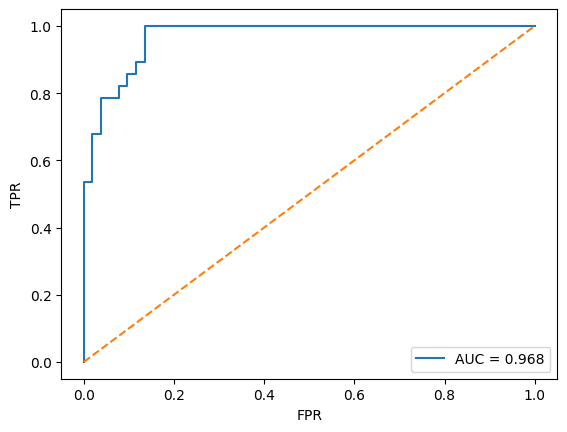

In [45]:
prob = modelo.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test,prob)
fpr,tpr,_ = roc_curve(y_test,prob)

plt.plot(fpr,tpr,label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

In [46]:
print(resultado.summary())

                           Logit Regression Results                           
Dep. Variable:              Purchased   No. Observations:                  400
Model:                          Logit   Df Residuals:                      397
Method:                           MLE   Df Model:                            2
Date:                Mon, 29 Jun 2026   Pseudo R-squ.:                  0.4688
Time:                        19:17:59   Log-Likelihood:                -138.53
converged:                       True   LL-Null:                       -260.79
Covariance Type:            nonrobust   LLR p-value:                 7.995e-54
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -12.4340      1.300     -9.566      0.000     -14.982      -9.886
Age                 0.2335      0.026      9.013      0.000       0.183       0.284
EstimatedSalary   3.59e-05   5.4

O modelo de regressão logística apresentou coeficientes estatisticamente significativos para Idade e Salário (p < 0,05), indicando que ambas as variáveis influenciam a probabilidade de compra de uma SUV. O sinal positivo dos coeficientes mostra que, à medida que idade ou salário aumentam, aumenta também a chance de compra.

In [47]:
odds = np.exp(resultado.params)
odds

const              0.000004
Age                1.262999
EstimatedSalary    1.000036
dtype: float64

In [49]:
ic = np.exp(resultado.conf_int())
ic.columns = ['Limite Inferior','Limite Superior']
ic

,Limite Inferior,Limite Superior
const,3.116065e-07,0.000051
Age,1.200471e+00,1.328785
EstimatedSalary,1.000025e+00,1.000047


In [50]:
odds_ratio = pd.DataFrame({
    'Coeficiente': resultado.params,
    'Odds Ratio': np.exp(resultado.params),
    'p-valor': resultado.pvalues
})

odds_ratio

,Coeficiente,Odds Ratio,p-valor
const,-12.433988,0.000004,1.109389e-21
Age,0.233489,1.262999,2.007792e-19
EstimatedSalary,0.000036,1.000036,3.774246e-11


Age = 1,12: cada aumento de 1 ano na idade aumenta em aproximadamente 12% as chances de comprar uma SUV, mantendo o salário constante.


EstimatedSalary = 1,00003: cada aumento de R$ 1 no salário aumenta muito pouco a chance de compra. Para facilitar a interpretação, pode-se analisar aumentos de R$ 1.000 ou R$ 10.000.